In [1]:
#pip install tensorflow

In [2]:
#pip install pyswarm

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for pyswarm: filename=pyswarm-0.6-py3-none-any.whl size=4486 sha256=9cb329a5ed28ca87f77bcf305271e3532f9a8433873c8051c0f1936c3c7a6404
  Stored in directory: c:\users\lenovo\appdata\local\pip\cache\wheels\93\15\89\3970ef96abd6123028010a90f007c4e6a2bed700db0aa2d36a
Successfully built pyswarm
Note: you may need to restart the kernel to use updated packages.


In [29]:
# Import library
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.optimizers import Adam
from pyswarm import pso
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [5]:
# 1. Persiapan Data
np.random.seed(42)
Data = pd.read_excel('D:/Kerjaan/Project P67050125 (Neural Network with PSO)/Data.xlsx')
data = Data['Nilai']

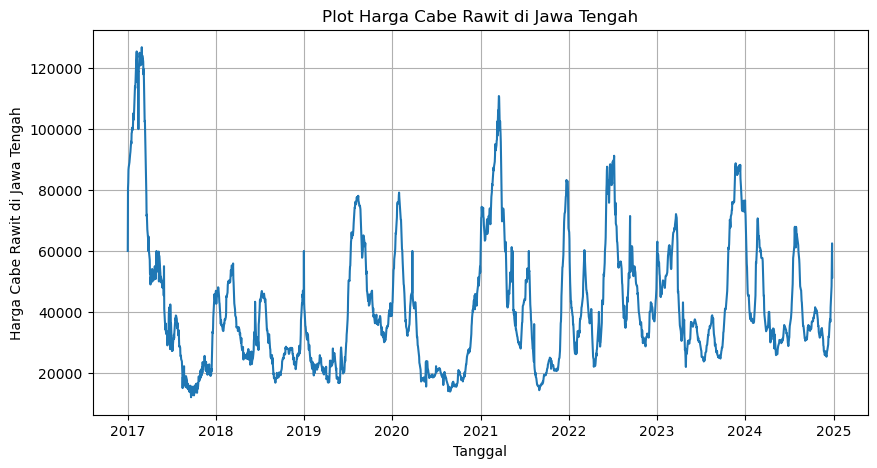

In [6]:
# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(Data['Tanggal'], Data['Nilai'])
plt.xlabel('Tanggal')
plt.ylabel('Harga Cabe Rawit di Jawa Tengah')
plt.title('Plot Harga Cabe Rawit di Jawa Tengah')
plt.grid(True)
plt.show()

Lag 0: 1.0
Lag 1: 0.9906493582581495
Lag 2: 0.00011717357395375918
Lag 3: -0.12582337903101587
Lag 4: -0.1322383412590459
Lag 5: -0.10152884973640341
Lag 6: -0.08729530043578826
Lag 7: -0.03529597855477413
Lag 8: 0.0005448433499871836
Lag 9: -0.04451981806906573
Lag 10: -0.053807512237141614
Lag 11: -0.0002314883615550202
Lag 12: -0.018540529860696285
Lag 13: -0.0061306709254723615
Lag 14: -0.02959243574978891
Lag 15: -0.00885581267769046
Lag 16: 0.04769527474334721
Lag 17: -0.05742049523878093
Lag 18: -0.012025775982239098
Lag 19: -0.022097756764618157
Lag 20: -0.008496309033695634


<Figure size 1000x500 with 0 Axes>

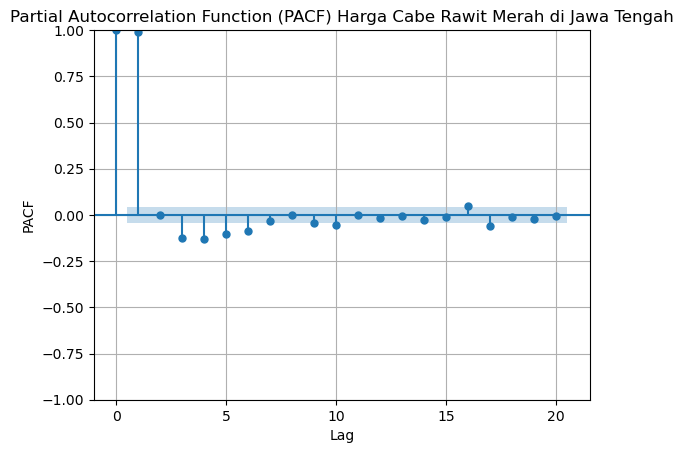

In [7]:
# Hitung nilai PACF
pacf_values = pacf(Data['Nilai'], nlags=20, method='ywm')

# Tampilkan nilai PACF
for i, val in enumerate(pacf_values):
    print(f"Lag {i}: {val}")

# Plot PACF
plt.figure(figsize=(10, 5))
plot_pacf(Data['Nilai'], lags=20) # Adjust lags as needed
plt.title('Partial Autocorrelation Function (PACF) Harga Cabe Rawit Merah di Jawa Tengah')
plt.xlabel('Lag')
plt.ylabel('PACF')
plt.grid(True)
plt.show()


In [40]:
# Fungsi untuk membuat dataset time series
def create_dataset(data, look_back=3):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

# Buat dataset dengan sliding window
look_back = 1
X, y = create_dataset(data, look_back)

In [41]:
# Normalisasi data
X_min, X_max = X.min(), X.max()
y_min, y_max = y.min(), y.max()
X = (X - X_min) / (X_max - X_min)
y = (y - y_min) / (y_max - y_min)

In [42]:
# Bentuk ulang data untuk LSTM (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [11]:
# 2. Definisikan Fungsi Objektif untuk PSO
def objective_function(params):
    neurons = int(params[0])  # Jumlah neuron dalam LSTM
    learning_rate = params[1]  # Learning rate

    # Bangun model LSTM
    model = Sequential([
        LSTM(neurons, activation='relu', input_shape=(look_back, 1)),
        Dense(1)
    ])

    # Kompilasi model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')

    # Latih model pada data pelatihan
    model.fit(X, y, epochs=3, batch_size=2, verbose=0)

    # Evaluasi pada data pelatihan
    loss = model.evaluate(X, y, verbose=2)
    return loss  # Kembalikan nilai loss untuk PSO

In [13]:
# 3. Jalankan PSO
# Variasi nilai c1 dan c2
c1_values = [0.5, 1, 1.5, 2]
c2_values = [0.5, 1, 1.5, 2]

results = []

for c1 in c1_values:
    for c2 in c2_values:
        # Batasan untuk jumlah neuron dan learning rate
        lb = [5, 0.001]  # Lower bound
        ub = [30, 0.01]  # Upper bound

        # Jalankan PSO
        xopt, fopt = pso(objective_function, lb, ub, swarmsize=5, maxiter=3, omega=0.5, phip=c1, phig=c2)

        results.append({'c1': c1, 'c2': c2, 'xopt': xopt, 'fopt': fopt})

# Buat DataFrame dari hasil
results_df = pd.DataFrame(results)

# Temukan model terbaik
best_model_index = results_df['fopt'].idxmin()
best_model = results_df.loc[best_model_index]

print("Hasil PSO untuk setiap kombinasi c1 dan c2:")
print(results_df)
print("\nModel terbaik:")
best_model

64/64 - 0s - 3ms/step - loss: 7.5411e-04
64/64 - 0s - 3ms/step - loss: 7.7561e-04
64/64 - 0s - 3ms/step - loss: 0.0011
64/64 - 0s - 3ms/step - loss: 0.0011
64/64 - 0s - 4ms/step - loss: 8.2606e-04
64/64 - 0s - 3ms/step - loss: 7.5787e-04
64/64 - 0s - 6ms/step - loss: 6.8604e-04
64/64 - 0s - 4ms/step - loss: 7.4132e-04
64/64 - 0s - 4ms/step - loss: 0.0012
64/64 - 0s - 4ms/step - loss: 0.0010
64/64 - 0s - 4ms/step - loss: 7.1135e-04
64/64 - 0s - 4ms/step - loss: 6.5956e-04
64/64 - 0s - 4ms/step - loss: 0.0013
64/64 - 0s - 4ms/step - loss: 7.5591e-04
64/64 - 0s - 5ms/step - loss: 7.1219e-04
64/64 - 0s - 4ms/step - loss: 7.5058e-04
64/64 - 0s - 4ms/step - loss: 9.8131e-04
64/64 - 0s - 4ms/step - loss: 7.4957e-04
64/64 - 0s - 4ms/step - loss: 7.7216e-04
64/64 - 0s - 3ms/step - loss: 6.9549e-04
Stopping search: maximum iterations reached --> 3
64/64 - 0s - 4ms/step - loss: 8.7750e-04
64/64 - 0s - 5ms/step - loss: 0.0010
64/64 - 0s - 4ms/step - loss: 7.3935e-04
64/64 - 0s - 4ms/step - loss: 8

c1                                            1.5
c2                                            1.5
xopt    [5.327361414708341, 0.006971836348150396]
fopt                                     0.000642
Name: 10, dtype: object

In [25]:
results_df.to_excel('Result.xlsx')

In [21]:
# 4. Latih Model Terbaik
best_neurons = int(best_model['xopt'][0])
best_learning_rate = best_model['xopt'][1]

# Bangun model terbaik
best_model = Sequential([
    LSTM(best_neurons, activation='relu', input_shape=(look_back, 1)),
    Dense(1)
])
best_model.compile(optimizer=Adam(learning_rate=best_learning_rate), loss='mse')

# Latih model terbaik
history = best_model.fit(X, y, epochs=1000, batch_size=16, verbose=1)

Epoch 1/1000


c:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0313
Epoch 2/1000
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.6922e-04
Epoch 3/1000
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.4480e-04
Epoch 4/1000
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.1261e-04
Epoch 5/1000
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.3828e-04
Epoch 6/1000
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.0992e-04
Epoch 7/1000
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.1592e-04
Epoch 8/1000
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9914e-04
Epoch 9/1000
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.1955e-04
Epoch 10/1000
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.8368e-04
Epoch 11/1000
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.2311e-04
Epoch 12/1000
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.6161e-04
Epoch 13/1000
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.5913e-04
Epoch 14/1000
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7

In [43]:
# 5. Prediksi dan Visualisasi
# Prediksi menggunakan model terbaik
predictions = best_model.predict(X)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [45]:
# Denormalisasi hasil prediksi dan target
predictions = predictions * (y_max - y_min) + y_min
y_actual = y * (y_max - y_min) + y_min

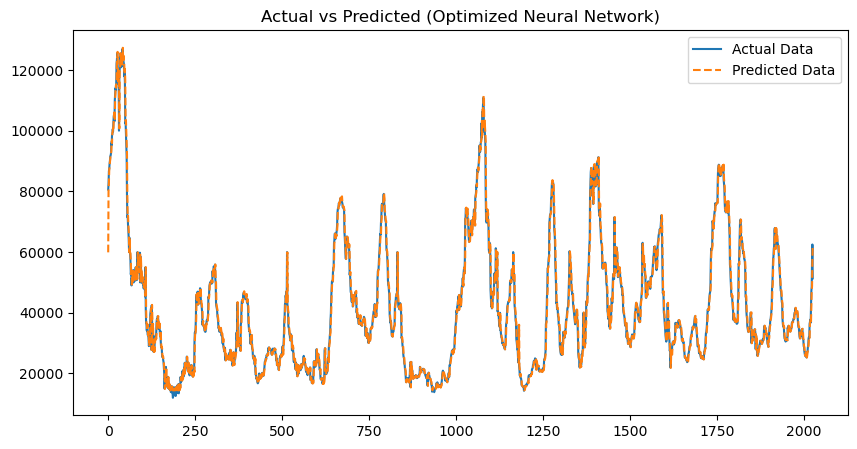

In [46]:
# Plot hasil prediksi vs aktual
plt.figure(figsize=(10, 5))
plt.plot(y_actual, label="Actual Data")
plt.plot(predictions, label="Predicted Data", linestyle='--')
plt.legend()
plt.title("Actual vs Predicted (Optimized Neural Network)")
plt.show()

In [49]:
# 6. Hitung RMSE dan akurasi dari model terbaik
# Menghitung MAE
mae = mean_absolute_error(y_actual, predictions)
print(f"MAE (Mean Absolute Error): {mae:.2f}")

# Menghitung RMSE
rmse = np.sqrt(mean_squared_error(y_actual, predictions))
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")

MAE (Mean Absolute Error): 1735.64
RMSE (Root Mean Squared Error): 2921.38


In [24]:
# 7. Prediksi 1 Waktu ke Depan
# Ambil data terakhir untuk prediksi
last_data = data[-look_back:].values.reshape(1, look_back, 1)

# Normalisasi data terakhir
last_data_normalized = (last_data - X_min) / (X_max - X_min)

# Lakukan prediksi
next_prediction_normalized = best_model.predict(last_data_normalized)

# Denormalisasi prediksi
next_prediction = next_prediction_normalized * (y_max - y_min) + y_min

# Tampilkan prediksi
print(f"Prediksi nilai untuk 1 waktu ke depan: {next_prediction[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Prediksi nilai untuk 1 waktu ke depan: 51596.03722766042
